### Librerias e importaciones

In [1]:
import sys
sys.path.append("..")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import lightgbm
import catboost


In [3]:
from src.preprocessing_prueba import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from src.data_splitting import train_val_split
from src.plots import eda_visualizacion_suvs, plot_precio_segun_antiguedad_km, plot_precio_segun_rango_ant, plot_dispersion_por_marca
from src.modelos.xgboost import entrenar_xgboost, entrenar_xgboost_ohe

In [4]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

### EDA

**Preprocessing**

In [5]:
data = pd.read_csv('../data/raw/pf_suvs.csv')

In [5]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())



 Dataset ALEATORIO
       Unnamed: 0    Marca     Modelo     Año  \
13039       13039     Jeep  Commander  2024.0   
343           343     Jeep    Compass  2024.0   
7446         7446  Citroën  C4 Cactus  2020.0   
12938       12938   Nissan      Kicks  2025.0   
1736         1736     BAIC        X55  2018.0   

                               Versión   Color Tipo de combustible  Puertas  \
13039  2.0 Td380 At9 4x4 7pas Overland   Negro              Diésel      5.0   
343           1.3 T270 Serie-S 4X2 At6  Blanco               Nafta      5.0   
7446               1.6 Vti 115 Feel Pk   Negro               Nafta      5.0   
12938             1.6 Advance Cvt Plus    Rojo               Nafta      5.0   
1736                    1.5t Elite Cvt  Blanco               Nafta      5.0   

      Transmisión Motor Tipo de carrocería Con cámara de retroceso Kilómetros  \
13039  Automática   2.0                SUV                      Sí        0.0   
343    Automática   1.3                SUV      

In [6]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [7]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


*El análisis exploratorio permitió detectar la existencia de valores faltantes en diversas variables descriptivas del vehículo, entre ellas Color, Transmisión, Motor y Con cámara de retroceso. Debido a que estas variables pueden influir significativamente en el valor de mercado de una SUV, se optó por imputar los datos faltantes en lugar de descartar las observaciones correspondientes, preservando así el tamaño de la muestra disponible para entrenamiento.*

*Por otra parte, se observó que gran parte de los atributos del dataset se encuentran representados mediante variables categóricas de tipo texto. Dado que los algoritmos de aprendizaje supervisado utilizados trabajan sobre representaciones numéricas, será necesario transformar dichas variables mediante One-Hot Encoding, generando una codificación binaria que permita incorporar esta información al modelo sin introducir relaciones artificiales entre categorías*

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

**Justificacion de desiciones tomadas**


1. ` La variable Unnamed` 0 actúa únicamente como identificador de cada publicación y no aporta información relevante para la predicción del precio, por lo que fue eliminada. 
Para `Tipo de carroceria`, el dataset contiene exclusivamente vehículos SUV, por lo que tambien fue eliminada.

2. `Cambio de moneda a USD` : Al tratarse de la variable objetivo del problema, fue necesario unificar todas las observaciones en una única moneda (USD) de referencia para garantizar la comparabilidad entre vehículos. Se eliminó la columna ya que no aportaba informacion.

3. `Titulo`: Gran parte de la información contenida en esta columna ya se encuentra representada en otras variables estructuradas del dataset (marca, modelo, motor, versión, etc.), por lo que se decidió eliminarla para evitar redundancia.


4. `Imputacion de Puertas`: se observaron valores inconsistentes en la variable Puertas. Dado que el conjunto de datos contiene exclusivamente SUVs, se decidió homogeneizar los valores restantes utilizando cinco puertas como valor por defecto

In [8]:
display(data["Puertas"].value_counts().sort_index())

Puertas
2.0           10
3.0          105
4.0          399
5.0        17731
6.0            3
7.0            2
60252.0        4
Name: count, dtype: int64

5. `Motor`: presentaba únicamente 38 valores faltantes (menos del 0.3% del dataset). Debido a su baja proporción, se optó por eliminar dichas observaciones en lugar de imputarlas para evitar introducir ruido artificial. A su vez , los datos estaban en str se cambiaron a valor numerico.

    Además la columna contená formatos muy heterogéneos, combinando cilindrada, tipo de motor y descripciones comerciales (por ejemplo: *"2.0 TSI"*, *"1.5 Turbo"*, *"Inyección Multipunto"* o *"Turboalimentado"*).

    Para preservar la mayor cantidad de información posible se descompuso en varias variables:
    **Motor_Litros**, **Motor_Turbo**, **Motor_Multipunto**, **Motor_Diesel**, **Motor_Hibrido** ,  **Motor_Litros_Faltante**.

    De esta forma se evita descartar observaciones y se conserva información relevante sobre la motorización del vehículo en un formato apto para modelos supervisados.

In [9]:
nulos_motor = data["Motor"].isna().sum()
total = len(data)

print(f"Nulos en Motor: {nulos_motor}")
print(f"Total de registros: {total}")
print(f"Porcentaje de nulos: {100*nulos_motor/total:.3f}%")

Nulos en Motor: 38
Total de registros: 18254
Porcentaje de nulos: 0.208%


In [10]:
print(data["Motor"].unique().tolist())

['1.5', '2.0 L 230 CV  350 TSI', '1.4', '2.4', '1.5 TURBO', '2.0', '3.6', '1.8', '1.0', '1.3', '1.2 TURBO', '1.2', '1.6', 'Nafta 2.0 (148cv) + Electrico (184.5cv)', '3.0', '2.2', '2.5', '1', '2.5l Hibrida', '2.8', '2.7', 'TURBOALIMENTADO', 'TURBO DIESEL INYECCION', '4.8', '2.9', '1.3T', 'INYECCION MULTI PUNTO', nan, 'diesel', '4.4', '3.0 440HP', '2.0 hurrican 4 272 cv 400nm', '6.4', '5.2', '1.5t', '1.4 TFSI', '2.3', '4.7', '2.0 TDI 140CV', '3.7', '3.2', '1500', '3.8', '1.3 TURBO', '4.5', '3', '2', '2.0 TURBO', '4.0 Nafta', '1.8L', '192 HP', '1.6 Naftero', '5.0', '1.5 TURBO 185 HP', 'P8 (408hp)', '1,3 t 175 cv 270 Nm', '1.6 Turbo', '4.2', '4.0', '1.0 tsi', '1.5 16V', '1.0 200 TSI', '1.8 de 140 hp', '2.0 350TSI', '3.5', '1.3L', '1.3 Turbo', '1.0 TURBO', '1.3 TURBO NAFTA 175CV AT9', 'Motor naftero 1.8 105 CV 161 Nm', '1.0 3 CILINDROS', 'v8 302', '3.3 V6 TD 304cv 700 NM de torque', '1.5 turbo', 'TURBO 2 LITROS', '1.6 MSI Nafta', '1.0T', '6.1', '2500', '2.4L', 'V6 PLUG IN HYBRID 460HP', '2.

In [11]:
motor_extraido = (
    data["Motor"]
    .str.extract(r'(\d+[.,]\d+)')[0]
)

perdidos = data[
    data["Motor"].notna() &
    motor_extraido.isna()
]

print(len(perdidos))
display(perdidos["Motor"].value_counts().head(10)) 

429


Motor
INYECCION MULTI PUNTO      157
TURBOALIMENTADO             82
1                           67
2                           41
TURBO DIESEL INYECCION      10
Turbo 140 CV                 4
1600                         3
1500                         2
192 HP                       2
V6 PLUG IN HYBRID 460HP      2
Name: count, dtype: int64

En los casos donde la cilindrada no pudo recuperarse, se incorporó la variable indicadora **Motor_Litros_Faltante**, permitiendo al modelo distinguir entre motores con cilindrada conocida y desconocida.

6. `Kilometros`: Se transformó a valor numérico para garantizar un tratamiento consistente. Además se crea feature ¨0 Km¨ que indica vehiculo nuevo o usado. Además posteriormente se incorporó `Log_Km` para reducir la asimetria observada en la distribucion original.

7. `Descripcion` : contiene texto libre que no puede ser utilizado directamente por modelos de regresion tradicionales. Se construyó un score basado en palabras clave positivas y negativas asociadas al estado general del vehículo, documentación, mantenimiento y equipamiento. El resultado se transformó en una escala numérica entre 1 y 10.

8. `Marcas`:Se unifican las muestras de Marcas para evitar duplucados , y/o reconocimiento erroneo de una Marca. 
A su vez, se combinó `Marca `y `Modelo` en una sola feature `Marca_Modelo`

In [12]:
print(data["Marca"].unique().tolist())

['Ford', 'Volkswagen', 'Jeep', 'BAIC', 'Kia', 'Hyundai', 'Porsche', 'Peugeot', 'Fiat', 'Chevrolet', 'Citroën', 'BMW', 'Audi', 'Honda', 'Nissan', 'Mercedes-Benz', 'Renault', 'Suzuki', 'Toyota', 'D.S.', 'Chery', 'Daihatsu', 'SsangYong', 'Dodge', 'JAC', 'Land Rover', 'Alfa Romeo', 'Haval', 'Volvo', 'Lifan', 'Mini', 'D·S', 'Mitsubishi', 'Range Rover', 'Hiunday', 'Jetour', 'GWM', 'KAIYI', 'Lexus', 'Isuzu', 'Rrenault', 'Subaru', 'Jetur', 'DS AUTOMOBILES', 'hiunday', 'Jaguar', 'Vol']


8. `Año`: Considerando que se tiene 1 valor extremo, claro outlier o error de carga, se elimina la muestra ya que no aporta informacion ni se pierde al no tenerla.

In [13]:
display(pd.DataFrame(data['Año'].describe()))

,Año
count,18254.000000
mean,2042.796209
std,3217.260996
min,1981.000000
25%,2016.000000
50%,2019.000000
75%,2024.000000
max,436694.000000


In [14]:
print((data["Año"] > 2025).sum()) 
print(data[data["Año"] > 2025]["Año"].unique()) 

1
[436694.]


9. `Color`: considerando que se tienen colores definidos en mayuscula y minuscula, femenino y masculino, se unifican todas las muestras a minuscula masculino. A la vez, al haber pocas muestras de colores especificos, tales como 'gris titane' (1 sola muestra) o 'gris artense', el modelo no aprendera de estas, por lo que resulta conveniente unificarlas dentro de los colores genericos (en el caso de los ejemplos, dentro de 'gris). Asi se redujo la cardinalidad sin perder informacion relevante

In [15]:
print(data["Color"].value_counts().to_string())

Color
Gris                             5468
Blanco                           4809
Negro                            2825
Plateado                         1427
Azul                             1121
Rojo                             1118
Marrón                            253
Dorado                            190
Verde                             135
Beige                             125
Celeste                            93
Naranja                            73
Gris oscuro                        43
Violeta                            33
Bordó                              29
Amarillo                           24
Rosa                                8
Plata                               7
Otro                                6
Blanca                              4
Acero                               4
BLANCA                              3
Café                                3
Negra                               3
Gris plata                          3
steel_blue                          2
GRIS S

10. ` Versión ` : se agruparon las versiones en tres categroias, Version_Base, Version_Intermedia  y Version_Premium. Se clasificó utilizanod palabras clave frecuentes asociadas al nivel del equipamiento del veehículo.

11. ` Camara de retroceso`: tiene una gran cantidad de valores faltantes. Antes de realizar cualquier imputación estadística, se intentó recuperar esta información buscando referencias a cámaras o sensores de estacionamiento dentro de la descripción de cada vehículo. Cuando no fue posible inferir la presencia de la característica, el registro fue etiquetado como "Desconocido", permitiendo conservar la observación sin introducir supuestos adicionales.

In [6]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

Tamaño final del dataset ->  (18205, 21)


**NUEVO DATASET**

In [17]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
          Año   Color Tipo de combustible  Puertas Transmisión  \
12117  2025.0    azul               Nafta      5.0  Automática   
18020  2024.0    gris               Nafta      5.0  Automática   
13210  2025.0    gris               Nafta      5.0  Automática   
7471   2019.0  blanco               Nafta      5.0      Manual   
5575   2019.0  blanco               Nafta      5.0  Automática   

      Con cámara de retroceso  Kilómetros        Precio Tipo de vendedor  \
12117                      Sí         0.0  34976.265823    concesionaria   
18020             Desconocido         NaN  24525.316456    concesionaria   
13210             Desconocido         0.0  24580.696203           tienda   
7471                       Sí     73400.0  15031.645570       particular   
5575                       Sí     70000.0  23734.177215       particular   

             Marca_Modelo  ...  Motor_Litros  Motor_Turbo  Motor_Multipunto  \
12117     Volkswagen_Taos  ...          

In [18]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Año,float64,0,38
Color,str,379,16
Tipo de combustible,str,0,8
Puertas,float64,0,2
Transmisión,str,11,4
Con cámara de retroceso,str,0,3
Kilómetros,float64,431,2120
Precio,float64,0,2906
Tipo de vendedor,str,0,3
Marca_Modelo,str,0,144


**VISUALIZACION DEL EDA HASTA AHORA**

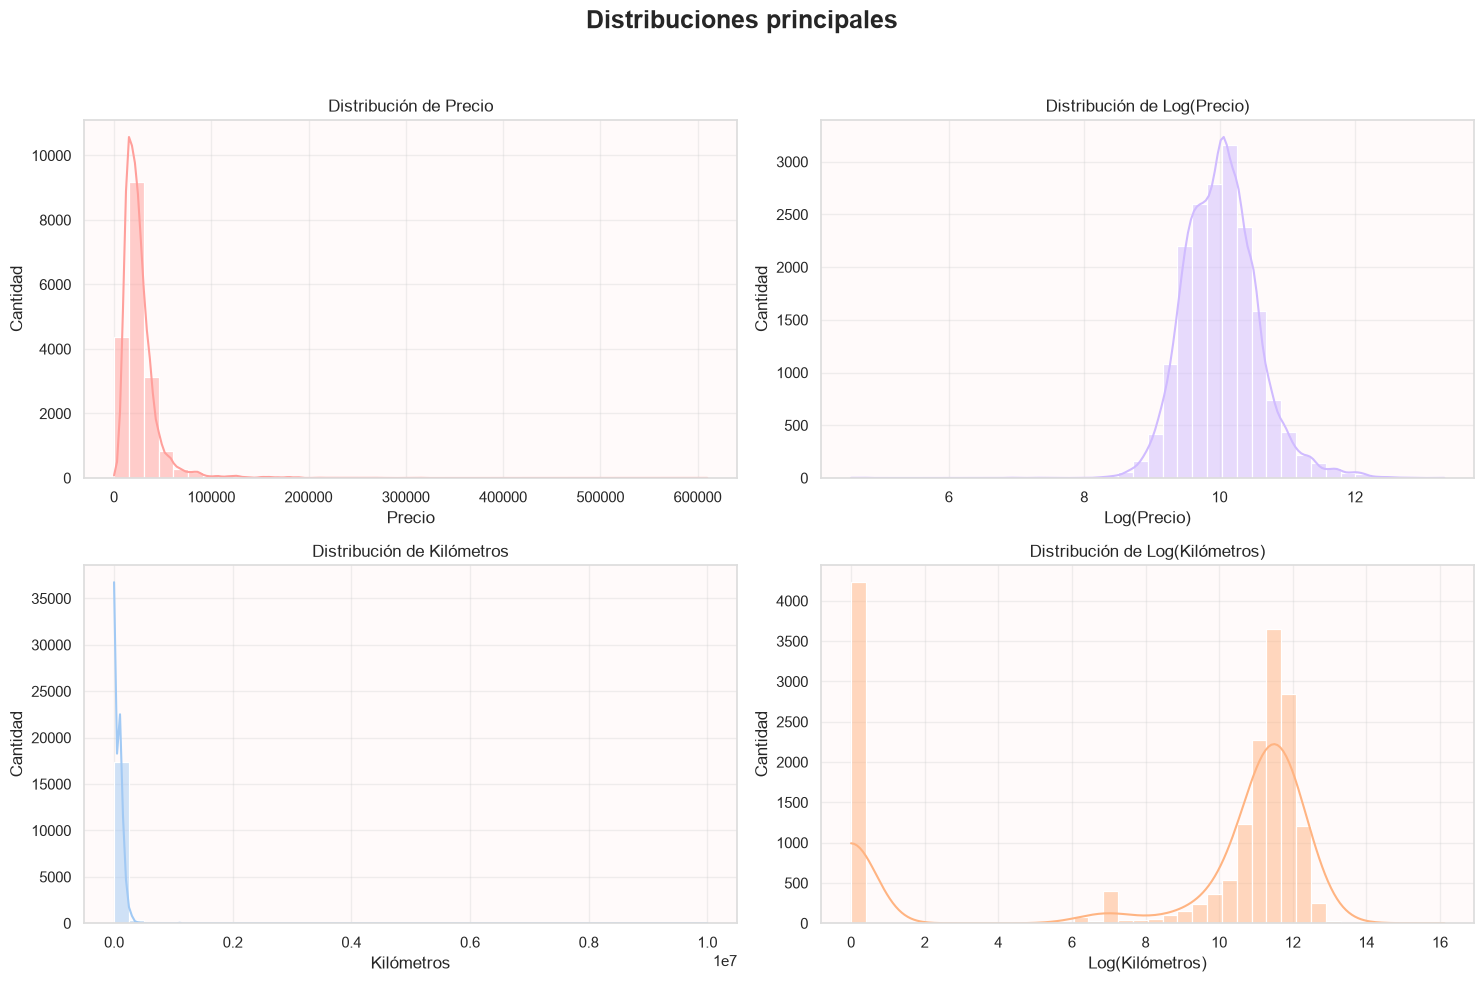

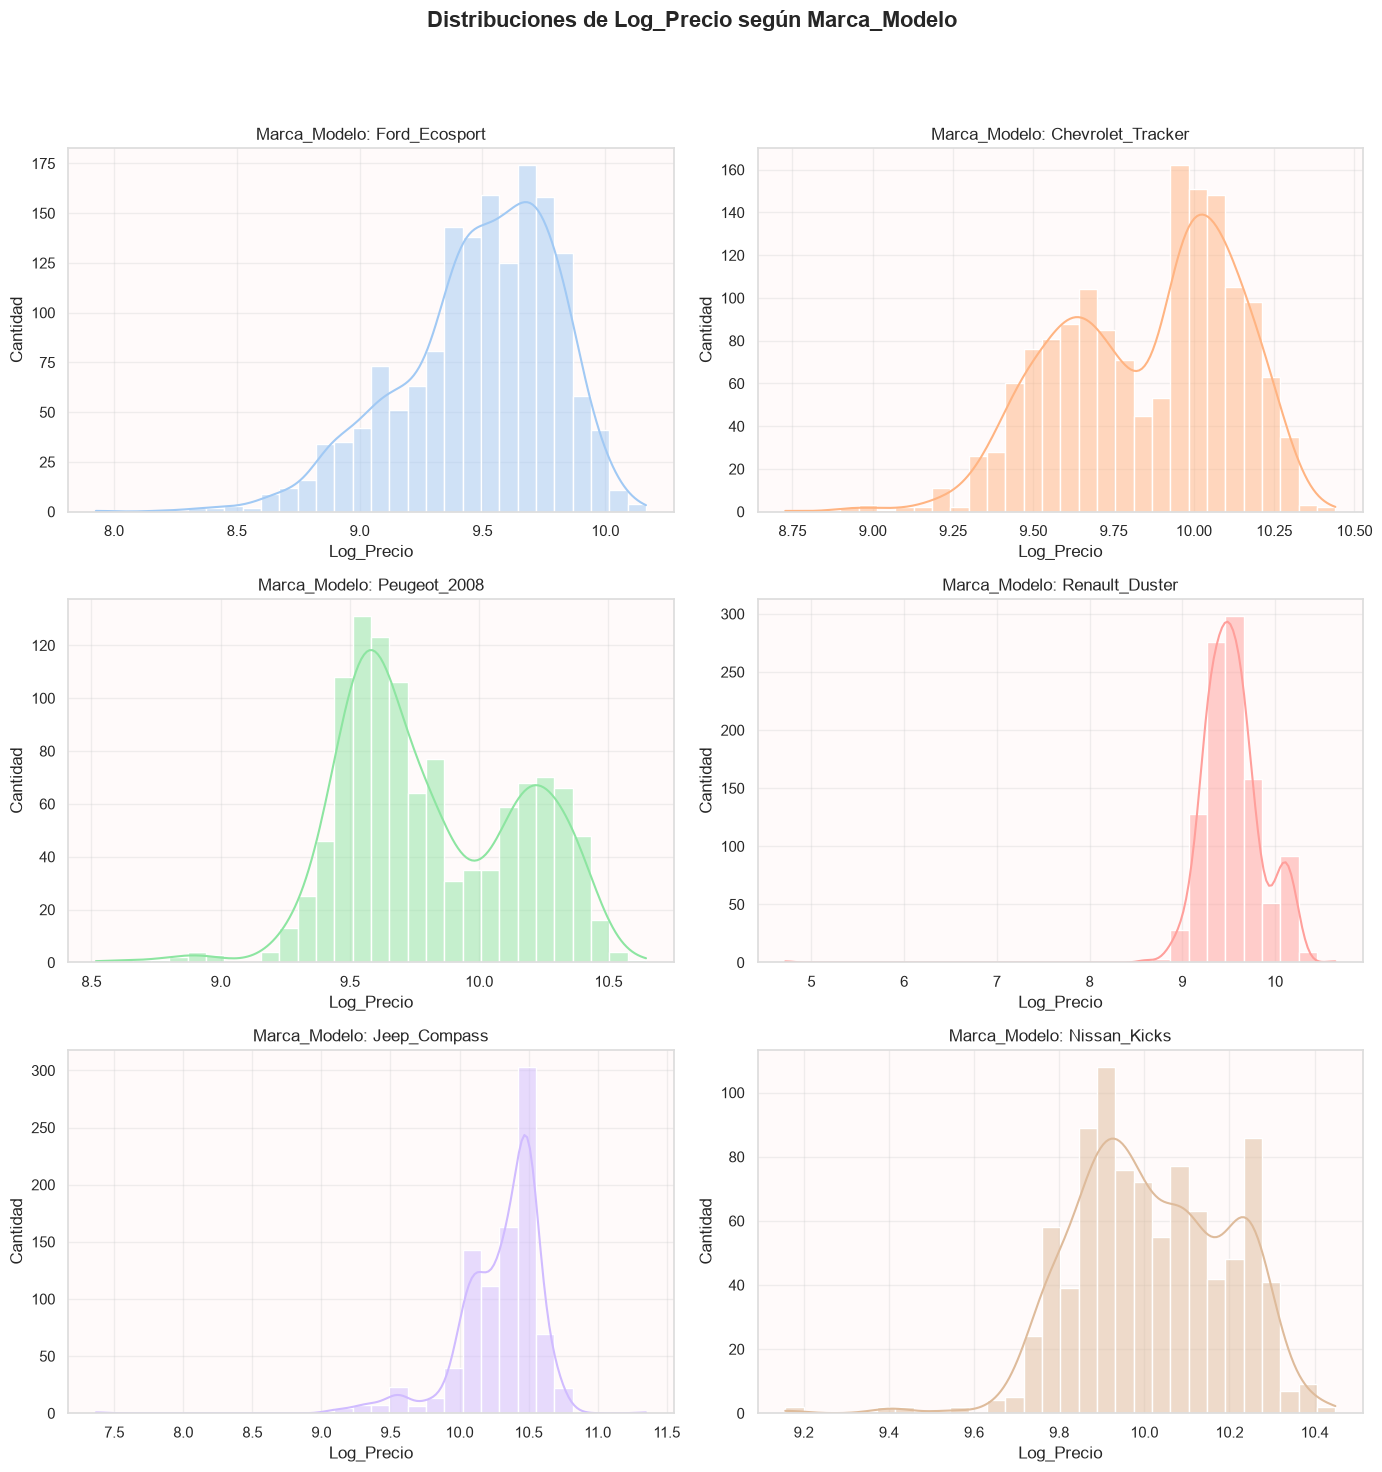

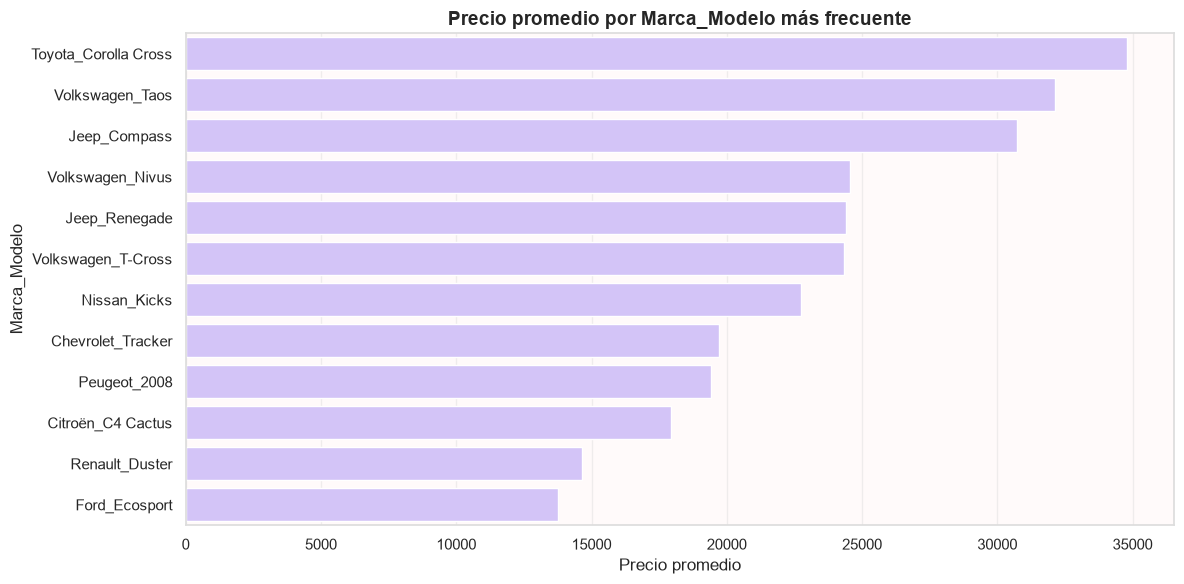

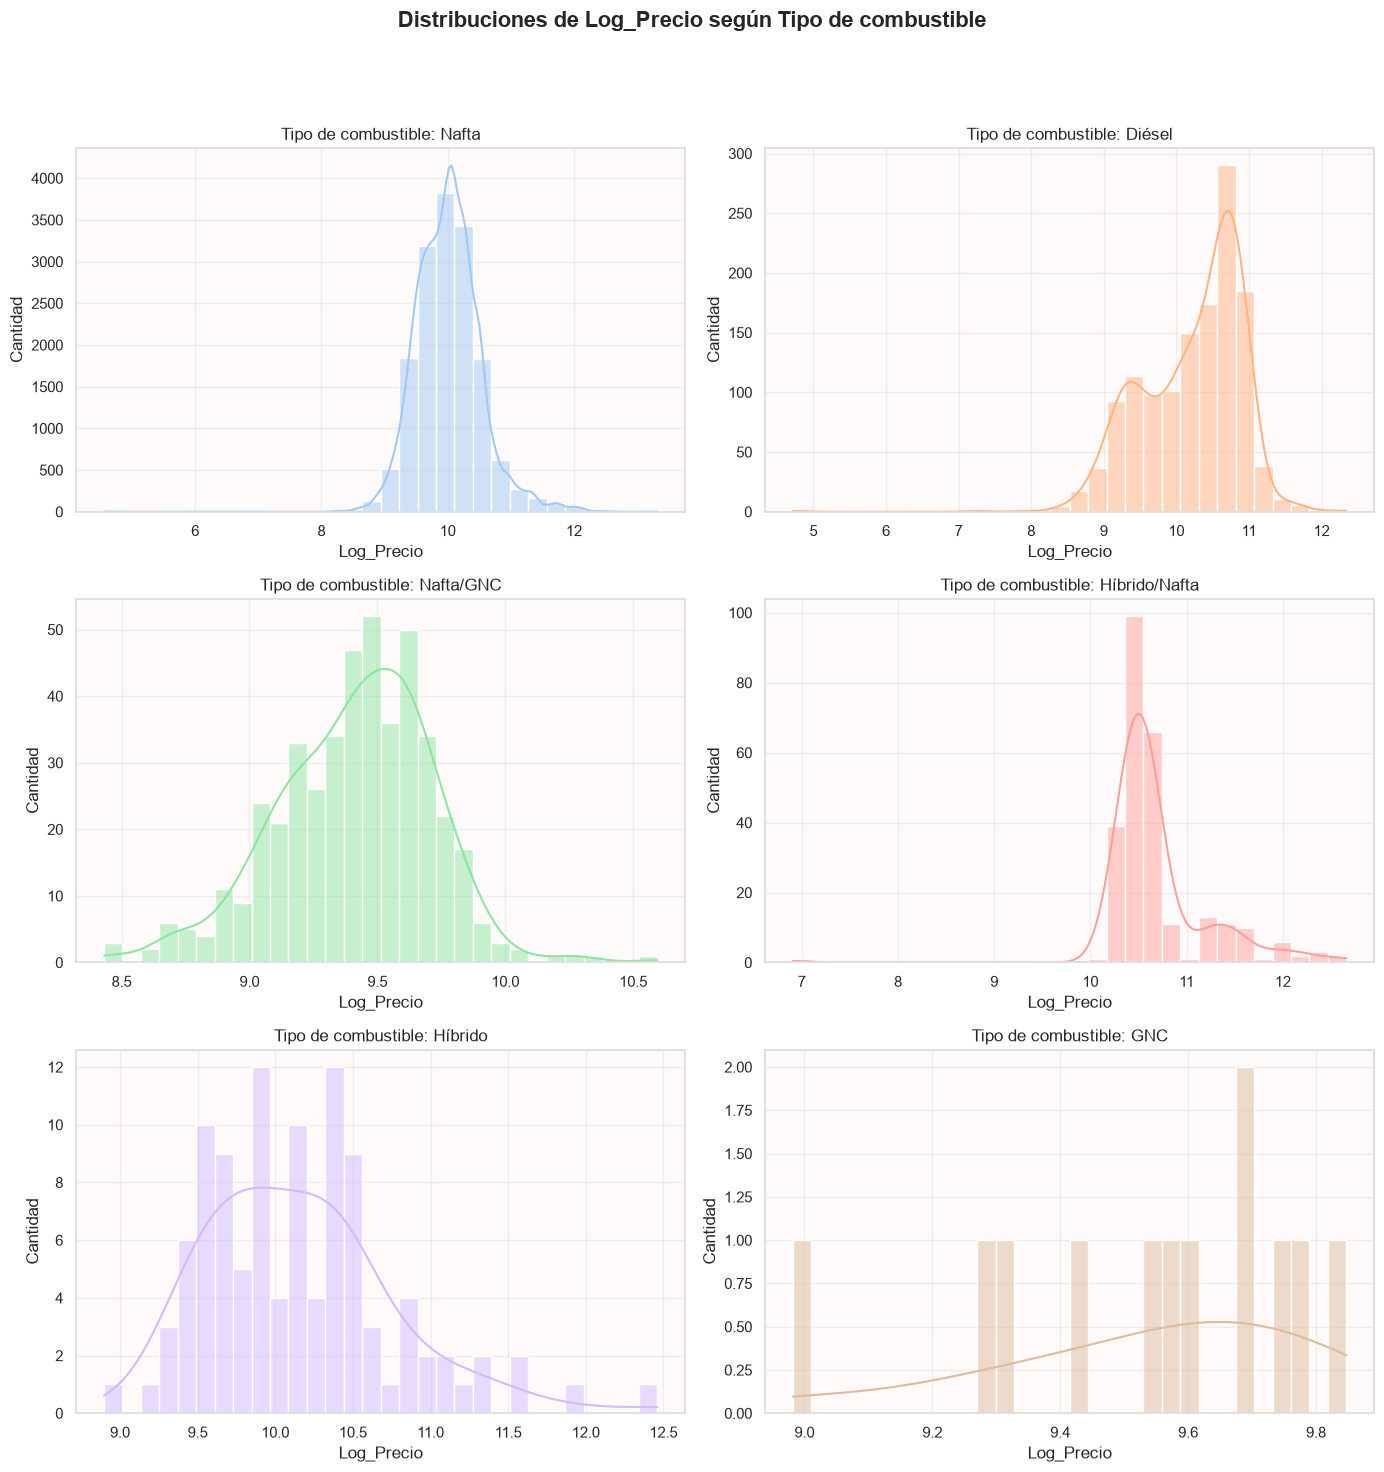

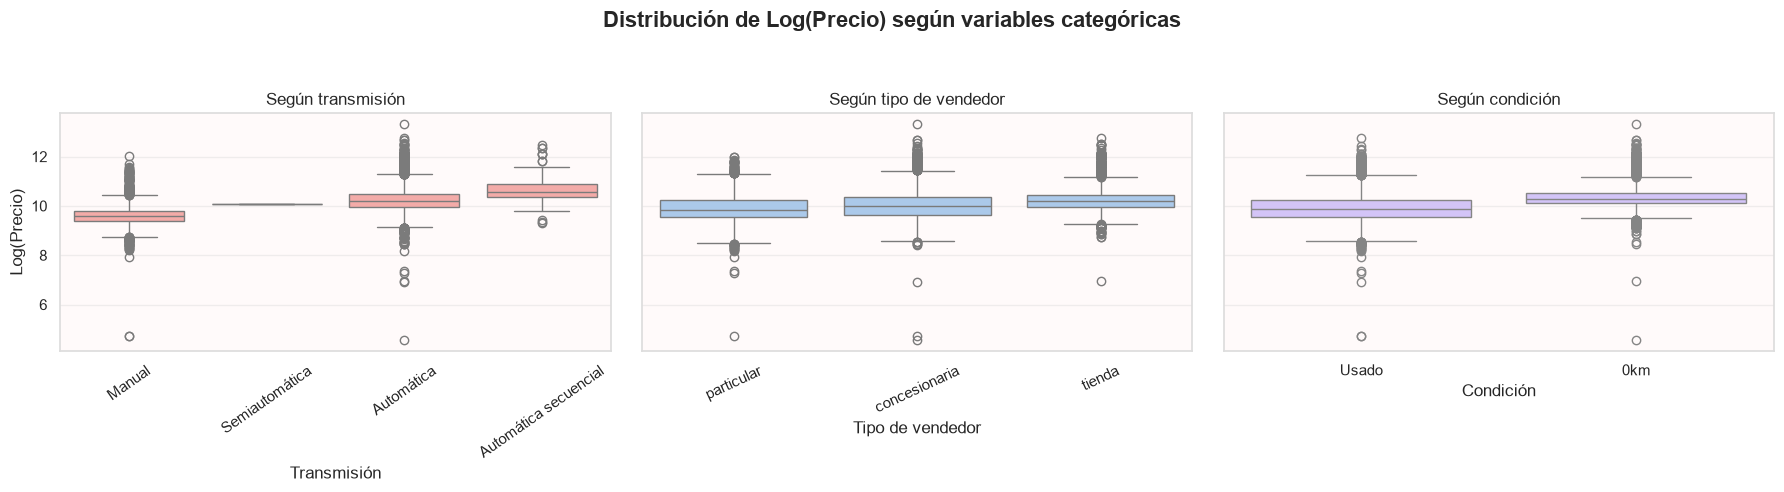

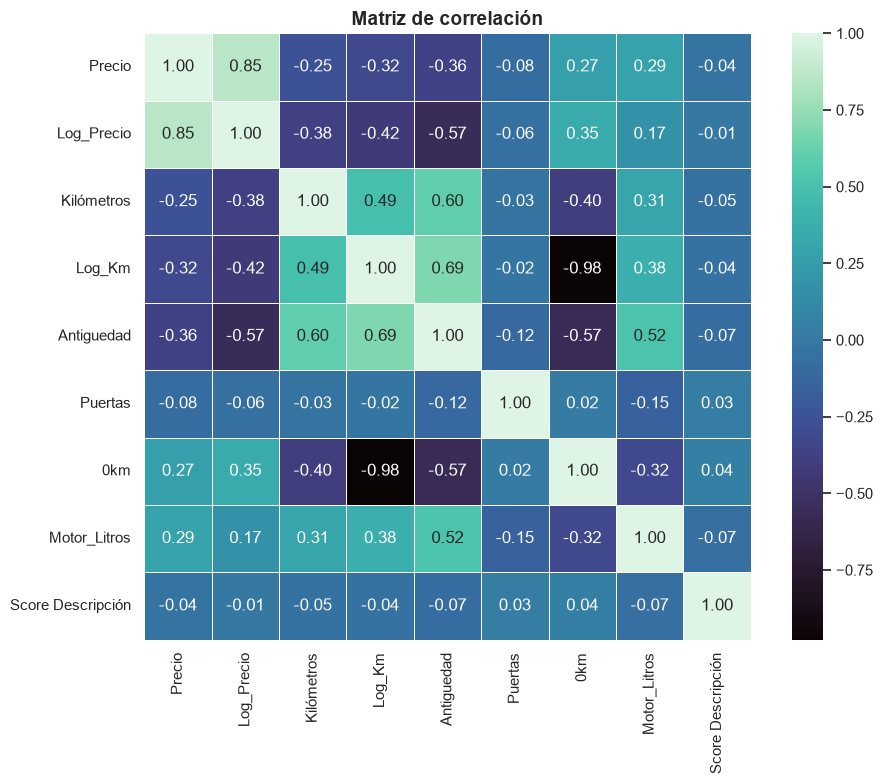

In [31]:
#Plots
eda_visualizacion_suvs(data_pre)

*Se observan diferencias de precio según el modelo, el combustible y la condición del vehículo. Además, tanto el kilometraje como la antigüedad presentan una relación negativa con el precio. Las transformaciones logarítmicas permiten visualizar mejor estas relaciones al reducir la asimetría de las distribuciones originales.*

Para terminar con el ***preprocesamiento de datos***, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "color", "transmision", "camara", "Kilómetros", "Motor_Litros" evitando el data leakage.

In [20]:
nulos = data_pre.isnull().sum()

if (nulos > 0).any():
    print("Columnas con NaN:")
    print(nulos[nulos > 0])
else:
    print("✅ No quedan NaN en el dataset")

Columnas con NaN:
Color           379
Transmisión      11
Kilómetros      431
Motor_Litros    427
dtype: int64


11. **Imputaciones realizadas después del split**: Todas las imputaciones basadas en estadísticas (moda o mediana) fueron calculadas exclusivamente sobre el conjunto de entrenamiento y posteriormente aplicadas al conjunto de validación, evitando data leakage.

- **Color:** los valores faltantes se completaron utilizando la moda del color para cada vehículo (`Marca_Modelo`). Si un modelo no poseía suficientes observaciones, se utilizó la moda global del conjunto de entrenamiento.

- **Transmisión:** debido a la baja cantidad de valores faltantes, se utilizó un imputador KNN entrenado sobre el conjunto de entrenamiento. La imputación se realizó considerando vehículos con características similares y posteriormente se reconstruyó la categoría original.

- **Kilómetros:** los valores faltantes se completaron utilizando la mediana del kilometraje correspondiente al año del vehículo. En caso de no existir suficientes observaciones para un determinado año, se utilizó la mediana global del conjunto de entrenamiento.

- **Motor_Litros:** cuando no fue posible recuperar la cilindrada a partir de la descripción original del motor, el valor faltante se imputó utilizando la mediana calculada sobre el conjunto de entrenamiento. Adicionalmente, se conservó la variable indicadora `Motor_Litros_Faltante` para que el modelo pudiera distinguir los registros originalmente incompletos.

In [7]:
train, val = train_val_split(data_pre)

Tamaño conjunto de entrenamiento -> (14564, 21), 
Tamaño conjunto de validación -> (3641, 21)


In [8]:
#Preprocessing post split usando los parametros del entrenamiento
x_train, x_val = preprocesamiento_post_split(train, val)

In [9]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ["Marca_Modelo","Color",'Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
X_train_final, X_val_final = onehot_encoding(x_train, x_val, columnas_oh)

In [10]:
print('Tamaño train final -> ', X_train_final.shape)
print('Tamaño val final -> ', X_val_final.shape)

Tamaño train final ->  (14564, 196)
Tamaño val final ->  (3641, 196)


In [44]:
# print('Final del preprocesamiento sobre Entrenamiento')
# summary = pd.DataFrame({
#     "dtype": X_train_final.dtypes,
#     "nulos": X_train_final.isnull().sum(),
#     "unicos": X_train_final.nunique()
# })

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

# display(summary)

In [45]:
# print('Final del preprocesamiento sobre Validación')
# summary_ = pd.DataFrame({
#     "dtype": X_val_final.dtypes,
#     "nulos": X_val_final.isnull().sum(),
#     "unicos": X_val_final.nunique()
# })

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

# display(summary_)

In [27]:
#Cargamos el set de entrenamiento y validacion a csv para ver los cambios
X_train_final.to_csv("../data/processed/X_train_EDA.csv", index=False)
X_val_final.to_csv("../data/processed/X_val_EDA.csv", index=False)

### **MODELOS**

#### **XGBoost**

In [11]:
X_train_xgboost = x_train.drop(columns = ['Precio'])
y_train_xgboost = train['Precio']

X_val_xgboost = x_val.drop(columns = ['Precio'])
y_val_xgboost = val['Precio']

modelo_xgboost, predicciones = entrenar_xgboost(X_train_xgboost, y_train_xgboost, X_val_xgboost, y_val_xgboost)

RMSE = 5311.83
R² = 0.93


In [ ]:

X_train_xgboost_oh = X_train_final.drop(columns = ['Precio'])
y_train_xgboost_oh = train['Precio']

X_val_xgboost = X_val_final.drop(columns = ['Precio'])
y_val_xgboost = val['Precio']

modelo_ohe, predicciones_ohe = entrenar_xgboost_ohe(X_train_xgboost_oh,y_train_xgboost_oh , X_val_xgboost, y_val_xgboost)

RMSE: 5971.99
R²:   0.9162


### **EXTENSIONES** 

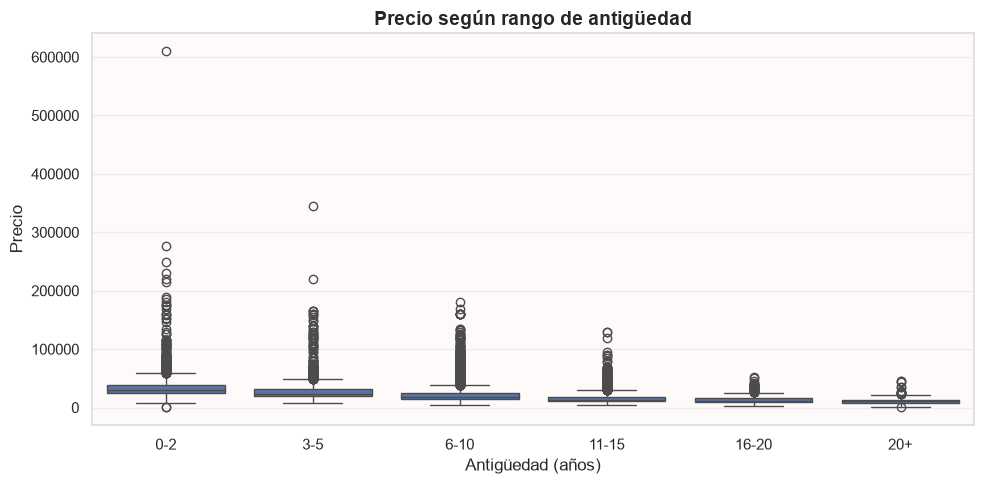

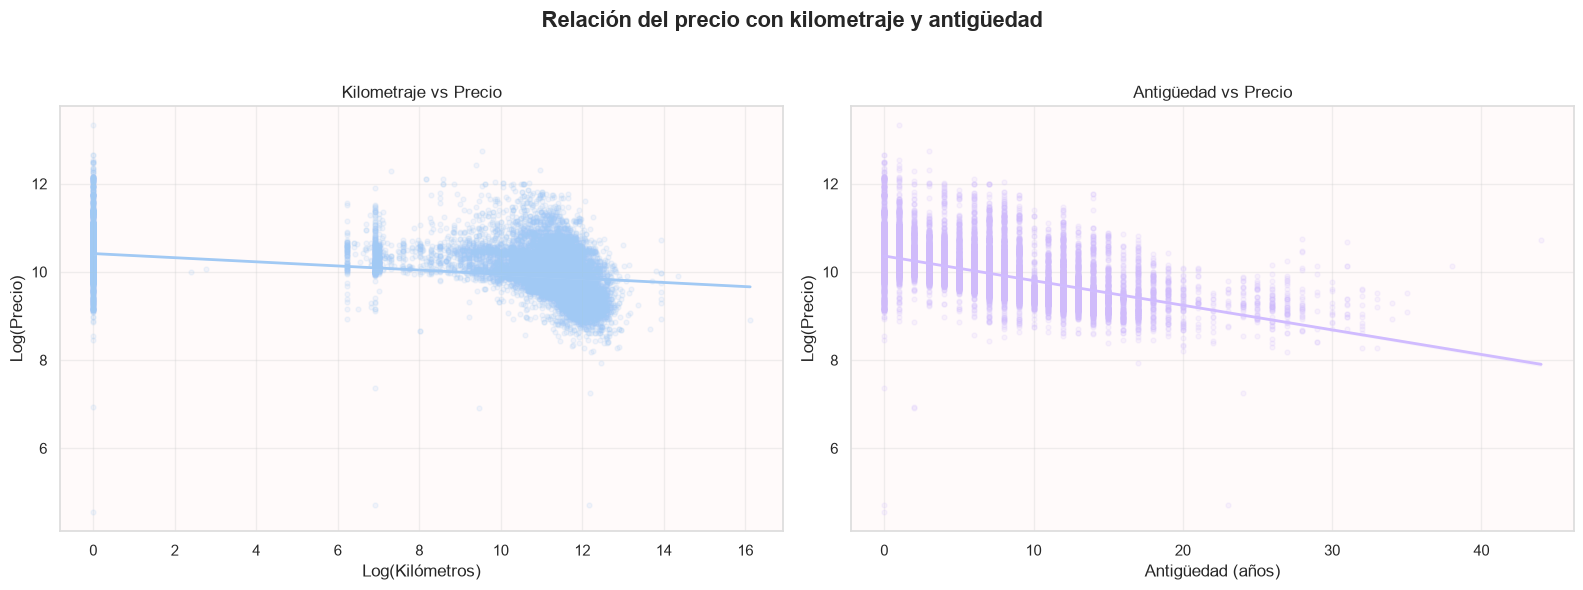

In [28]:
data_visualizacion = pd.concat([X_train_final, X_val_final], ignore_index = True)
data_visualizacion = data_visualizacion[data_visualizacion["Antiguedad"] <= 50]
plot_precio_segun_rango_ant(data_visualizacion)
plot_precio_segun_antiguedad_km(data_visualizacion)

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Podemos observar, tanto para la <strong>antigüedad</strong> como para el <strong>kilometraje</strong> (plot presentado en la seccion *Visualizacion EDA hasta ahora*) una clara tendencia. El primer gráfico muestra que a mayor años de uso, el precio del vehículo (en escala logarítmica) decrece de manera consistente. Los autos de 0-2 años concentran los precios más altos, rondando entre los e^10 y e^12 USD, mientras que los de más de 20 años, se ubican en rangos más bajos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El segundo gráfico confirma lo esperado: a mayor log(Km), menor log(Precio). Los vehículos 0km tienen precios más elevados, lo cual es consistente con la realidad; y la dispersión aumenta a medida que sube el kilometraje, lo que genera el desgaste del vehículo, impactando negativamente en su precio.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El boxplot por rangos de antiguedad refuerza ambas observaciones: la mediana de precio decae progresivamente, reduciéndose la dispersión en autos más antiguos. Los outliers más extremos se localizan en el rango de los 0-2 años, correspondiendo posiblemente, a vehículos de alta gama 0km.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Con esto se deja en evidencia la importancia de ambos features en relación con el precio para la generalización del modelo predictivo a entrenar.
</p>

In [29]:
#Definimos que las marcas con mas de 35 muestras sean las validas para calcular el Coeficiente de Variacion
marcas_validas = data['Marca'].value_counts()
marcas_validas = marcas_validas[marcas_validas >= 35].index
data_filtrado = data[data['Marca'].isin(marcas_validas)]

cv = data_filtrado.groupby('Marca')['Precio'].agg(['std', 'mean'])
cv["cv"] = cv["std"] / cv["mean"]
cv.sort_values("cv")

,std,mean,cv
Marca,,,
Fiat,1.080491e+07,2.331278e+07,0.463476
Citroën,1.144210e+07,2.086296e+07,0.548441
Volkswagen,1.755692e+07,2.845617e+07,0.616981
Peugeot,1.321951e+07,2.025624e+07,0.652614
Renault,1.039727e+07,1.523884e+07,0.682287
Chevrolet,1.501753e+07,2.181144e+07,0.688516
Nissan,1.503983e+07,2.145303e+07,0.701059
Chery,8.585606e+06,1.151105e+07,0.745858
Porsche,6.914162e+04,9.031488e+04,0.765562


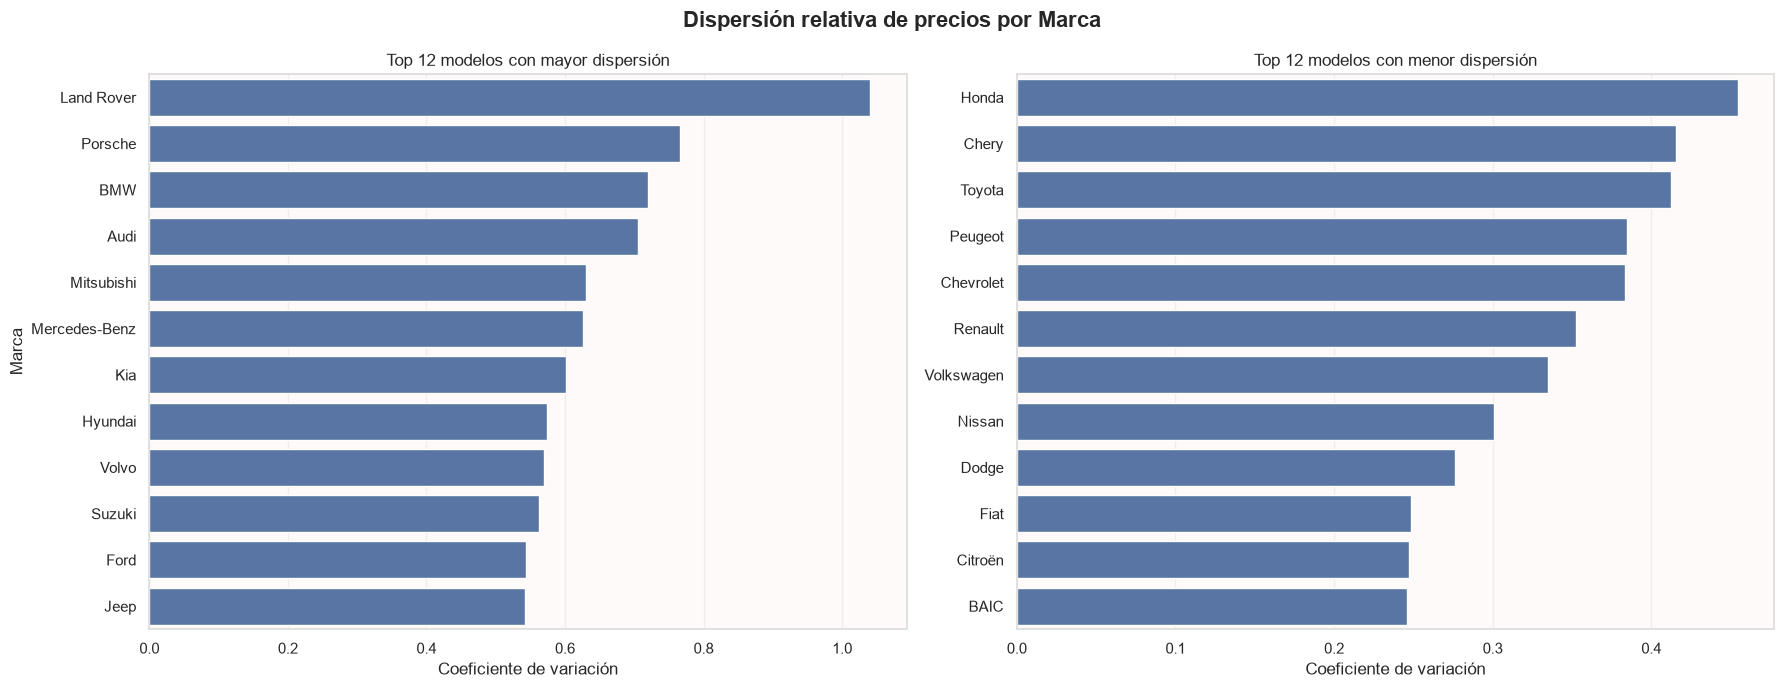

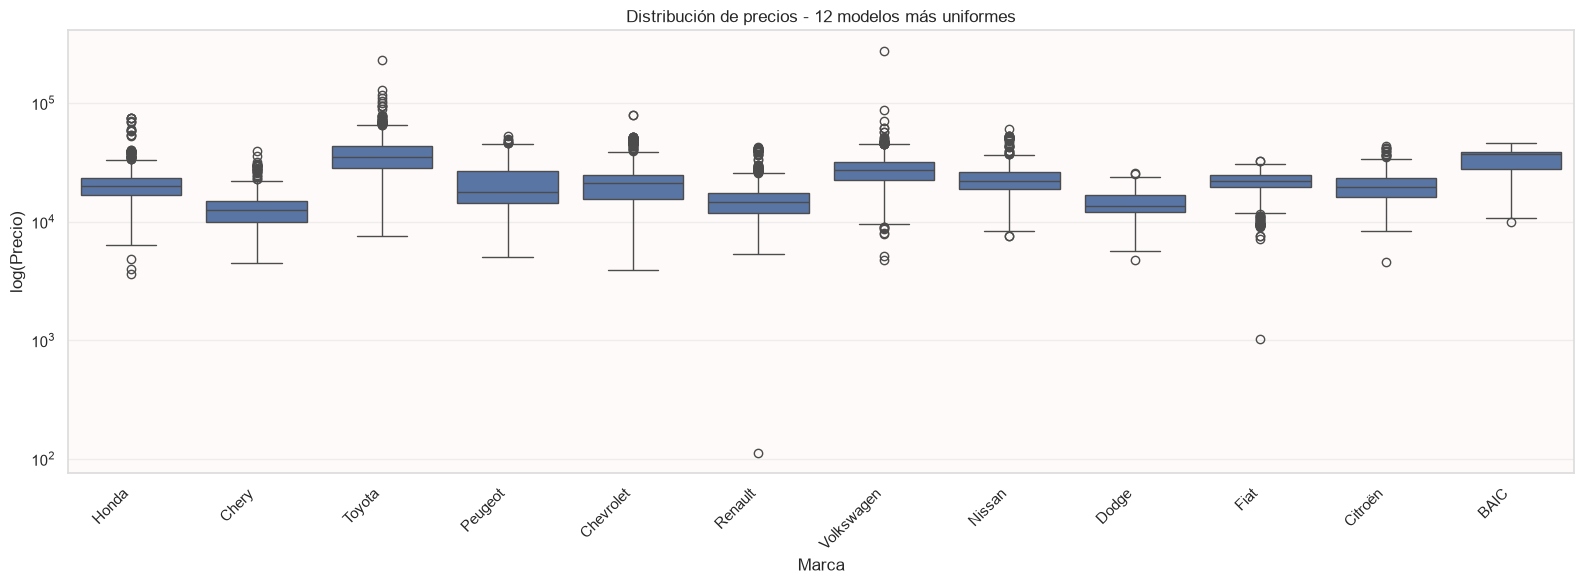

,count,mean,std,cv
Marca,,,,
BAIC,164,33385.697515,8205.122787,0.245768
Citroën,716,20008.738717,4941.296447,0.246957
Fiat,366,21134.120139,5246.884937,0.248266
Dodge,185,14655.239873,4050.876909,0.276412
Nissan,1059,22853.814667,6868.782889,0.300553
Volkswagen,2036,27599.984133,9247.423759,0.335052
Renault,1489,15421.173705,5430.961877,0.352176
Chevrolet,1747,21333.471212,8181.284593,0.383495
Peugeot,1247,20509.098743,7882.221094,0.384328


In [30]:
data_pre_con_marca = data_pre.copy()
data_pre_con_marca['Marca'] = data['Marca']
data_pre_con_marca = data_pre_con_marca[data_pre_con_marca["Precio"] < 350000]

plot_dispersion_por_marca(data_pre_con_marca, target= "Precio", min_muestras= 35, top_n=12)

In [ ]:
print(X_train_final["Score Descripción"].value_counts().sort_index())

Score Descripción
1     3666
2     6271
3     2579
4     1179
5      496
6      324
7       33
8       13
9        1
10       2
Name: count, dtype: int64


<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Las marcas con mayor dispersión resultan ser <strong>Land Rover</strong>, <strong>Porsche</strong> y <strong>BMW</strong>, tres marcas de lujo, lo cual explica este resultado: ofrecen modelos que van desde vehículos de entrada hasta vehículos de alta gama, lo que genera una gran variabilidad de precios dentro de sus modelos. El boxplot confirma esto con cajas amplias (particularmente en el caso de Porsche) y outliers con valores extremos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
En el extremo opuesto, encontramos a <strong>BAIC</strong>, <strong>Fiat</strong> y <strong>Citroën</strong>, que presentan la menor dispersión entre las marcas más predominantes del dataset. Se presentan como marcas con modelos más accesibles, los cuales se concentran en un rango de precio similar entre sí, y con un catálogo más acotado. Sus boxplots muestran cajas compactas y pocos outliers.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Lo observado a partir de la información provista coincide con lo esperable para este tipo de marcas, donde se tienen tanto modelos exclusivos como de segmento medio.
</p>

### Comparación entre modelos

### Final Model